<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA2/TALLER7/E7_RNN_LSTM_GRU_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 7

## Predict rating using RNN, LSTM and GRU



**INTEGRANTES:**

Luis Alejandro Garzón Ramirez

Zorayda Acevedo Jimenez

Yulieth Danitza Aguillón Ortega

Instalaciones varias

In [1]:
!pip install wget
!pip install livelossplot --quiet

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=0512ce6d9607ce14ea0b58f66b79932a4769d6fc743bd6c8d42b2aef2b9b8478
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget


In [ ]:
!pip install --upgrade --force-reinstall tensorflow==2.15.0 numpy==1.25.2
import os
os.kill(os.getpid(), 9)  # Reinicia el entorno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70

In [1]:
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.utils import pad_sequences

In [2]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [3]:
import pandas as pd

Importacion de los datos

In [4]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

In [5]:
plots = dataTraining['plot']
y = (dataTraining['rating'] >= dataTraining['rating'].mean()).astype(int)

In [6]:
plots

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."
...,...
8417,""" our marriage , their wedding . "" it ' s l..."
1592,"the wandering barbarian , conan , alongside ..."
1723,"like a tale spun by scheherazade , kismet fol..."
7605,"mrs . brisby , a widowed mouse , lives in a..."


In [7]:
y

,rating
3107,1
900,0
6724,1
4704,1
2582,1
...,...
8417,0
1592,0
1723,0
7605,1


# Exercise 7.1
Adecuación de los datos:
- Remove stopwords
- Lowercase
- split the text in words
- pad_sequences

In [8]:
import numpy as np
import pandas as pd
import wget
import os
from zipfile import ZipFile

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import string

from sklearn.model_selection import train_test_split

from livelossplot import PlotLossesKeras

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
# Primero aseguramos que las librerías necesarias estén instaladas
!pip install nltk

# Luego importamos las librerías necesarias
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import pandas as pd

# Descargar recursos necesarios
nltk.download('stopwords')
nltk.download('punkt')

# Definir el conjunto de stopwords
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess(text):
    text = text.lower()  # Convertir a minúsculas
    tokens = word_tokenize(text)  # Tokenizar el texto
    # Eliminar puntuaciones y stopwords
    tokens = [word for word in tokens if word not in string.punctuation and word not in stop_words]
    return ' '.join(tokens)
X=plots
# Aplicar la función de preprocesamiento
X = X.apply(preprocess)

# Mostrar el resultado
print(X)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


3107    story single father takes eight year old son w...
900     serial killer decides teach secrets satisfying...
6724    sweden female blackmailer disfiguring facial s...
4704    friday afternoon new york president tredway co...
2582    los angeles editor publishing house carol hunn...
                              ...                        
8417    `` marriage wedding `` lesson number one newly...
1592    wandering barbarian conan alongside goofy rogu...
1723    like tale spun scheherazade kismet follows rem...
7605    mrs brisby widowed mouse lives cinder block ch...
215     tinker bell journey far north never land patch...
Name: plot, Length: 7895, dtype: object


In [10]:
X = X.tolist()

In [11]:
# For vocabulary only the intersec characters is used to avoid issues with data collection
voc = set(''.join(X))
vocabulary = {x: idx + 1 for idx, x in enumerate(set(voc))}

El siguiente codigo recorta cada texto a un máximo de 2000 caracteres. Convierte cada carácter en un número usando un vocabulario (diccionario).

In [12]:
# Max len
max_len = 2000
X = [x[:max_len] for x in X]
# Convert characters to int and pad PAD SEQUENCE
X = [[vocabulary[x1] for x1 in x if x1 in vocabulary.keys()] for x in X]

In [13]:
len(X)

7895

In [14]:
X_pad = pad_sequences(X, maxlen=max_len)

In [15]:
X_pad

array([[ 0,  0,  0, ...,  6, 29, 57],
       [ 0,  0,  0, ...,  7, 53,  1],
       [ 0,  0,  0, ..., 28,  7, 25],
       ...,
       [ 0,  0,  0, ..., 34,  9, 56],
       [ 0,  0,  0, ..., 58,  5,  7],
       [ 0,  0,  0, ..., 53,  7,  7]], dtype=int32)

Se preparan y limpian los datos antes de entrenar un modelo de clasificación, asegurándose de que: No haya clases raras o únicas, Los datos estén balanceados, Y que todo tenga el mismo tamaño.

In [16]:
from sklearn.model_selection import train_test_split

# 🔹 Asegurar que X_pad e y tengan la misma longitud
if X_pad.shape[0] != y.shape[0]:
    min_samples = min(X_pad.shape[0], y.shape[0])
    X_pad = X_pad[:min_samples]
    y = y[:min_samples]

# 🔹 Verificar las clases en y
print("Distribución de clases antes de filtrar:")
print(y.value_counts())

# 🔹 Filtrar las clases que aparecen solo una vez
classes_to_remove = y.value_counts()[y.value_counts() == 1].index
mask = ~y.isin(classes_to_remove)

# 🔹 Aplicar la máscara de forma segura
X_pad_filtered = X_pad[mask]
y_filtered = y[mask]

# 🔹 Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X_pad_filtered, y_filtered, stratify=y_filtered, test_size=0.3, random_state=18
)

# 🔹 Verificación
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Distribución de clases antes de filtrar:
rating
1    4172
0    3723
Name: count, dtype: int64
Tamaño de X_train: (5526, 2000)
Tamaño de X_test: (2369, 2000)
Tamaño de y_train: (5526,)
Tamaño de y_test: (2369,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.3, random_state=18
)

# Verifica que la división se haya realizado correctamente
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (5526, 2000)
Tamaño de X_test: (2369, 2000)
Tamaño de y_train: (5526,)
Tamaño de y_test: (2369,)


# Exercise 7.2

Create a SimpleRNN neural network to predict the rating of a movie

Calculate the testing set accuracy

Este código crea y entrena una red neuronal con una capa RNN para clasificar texto en dos clases:

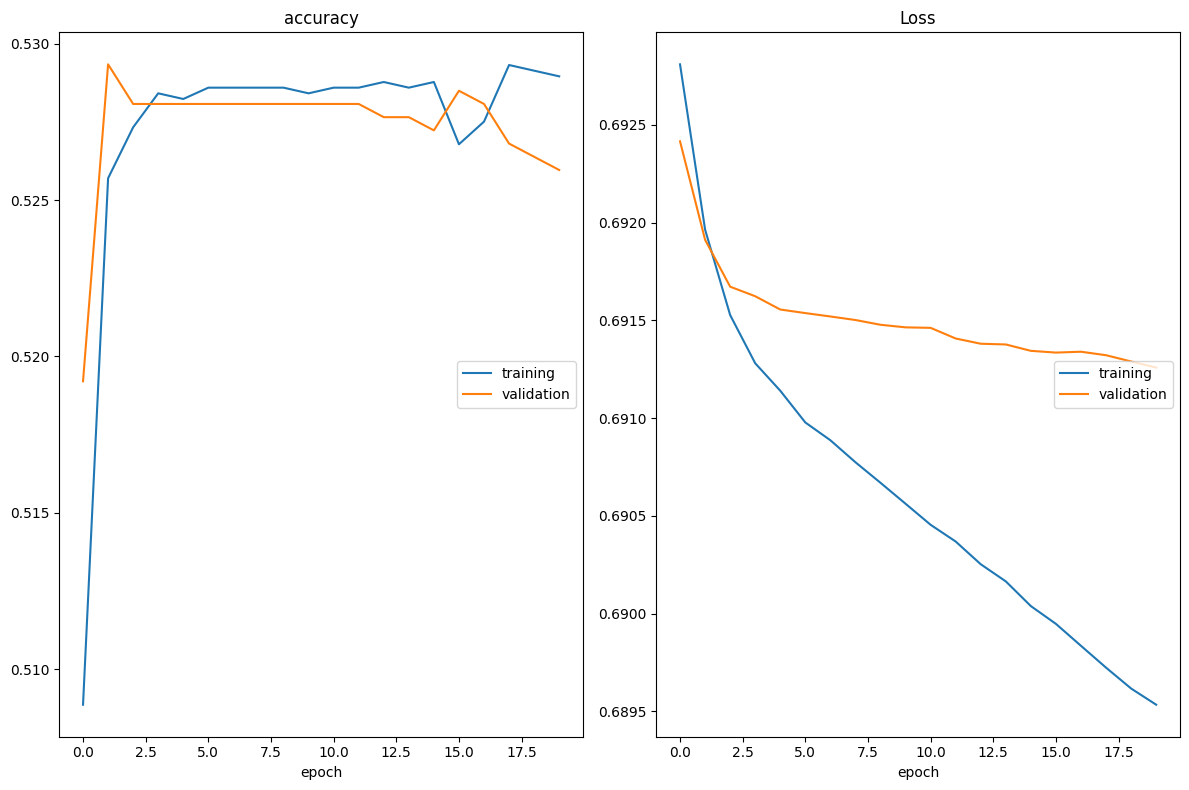

accuracy
	training         	 (min:    0.509, max:    0.529, cur:    0.529)
	validation       	 (min:    0.519, max:    0.529, cur:    0.526)
Loss
	training         	 (min:    0.690, max:    0.693, cur:    0.690)
	validation       	 (min:    0.691, max:    0.692, cur:    0.691)
44/44 [==============================] - 45s 1s/step - loss: 0.6895 - accuracy: 0.5290 - val_loss: 0.6913 - val_accuracy: 0.5260


In [18]:
import keras.optimizers as opts
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
from keras import backend as K

K.clear_session()

# Definir el modelo secuencial
model = Sequential()

# Capa de Embedding: salida de forma (batch_size, max_len, 128)
model.add(Embedding(input_dim=len(vocabulary) + 1, output_dim=128, input_length=max_len))

# Capa RNN que procesa la secuencia
model.add(SimpleRNN(units=64, activation='relu'))

# Capa de salida
model.add(Dense(1, activation='sigmoid'))

# Optimizador
op = opts.SGD(learning_rate=0.02)

# Compilación del modelo
model.compile(loss='binary_crossentropy', optimizer=op, metrics=['accuracy'])

# Resumen del modelo
model.summary()

# Entrenamiento
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          batch_size=128, epochs=20, verbose=1,
           callbacks=[PlotLossesKeras(), early_stop]
)

In [19]:
# Evaluar el modelo en los datos de prueba
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

75/75 [==============================] - 6s 86ms/step - loss: 0.6913 - accuracy: 0.5260
Test accuracy: 0.5259603261947632


# Exercise 7.3

Create a LSTM neural network to predict the rating of a movie

Calculate the testing set accuracy

In [20]:
from livelossplot import PlotLossesKeras
%matplotlib inline

Este código define un modelo LSTM para clasificar texto en dos clases, con regularización y preparado para entrenar.

In [21]:
K.clear_session()
model = Sequential()
model.add(Embedding(len(vocabulary) + 1, 128, input_length=max_len))
model.add(LSTM(32))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 2000, 128)         7552      
                                                                 
 lstm (LSTM)                 (None, 32)                20608     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 28193 (110.13 KB)
Trainable params: 28193 (110.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Este código crea un modelo de red neuronal con una capa LSTM personalizada (sin usar cuDNN) para clasificar texto en dos clases:

In [22]:
from keras.layers import LSTM

model = Sequential()
model.add(Embedding(len(vocabulary) + 1, 128, input_length=max_len))

# Desactivar cuDNN para LSTM
model.add(LSTM(32, activation='tanh', recurrent_activation='sigmoid'))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

Este código entrena el modelo con los datos de entrenamiento y muestra la evolución del rendimiento durante 20 épocas.

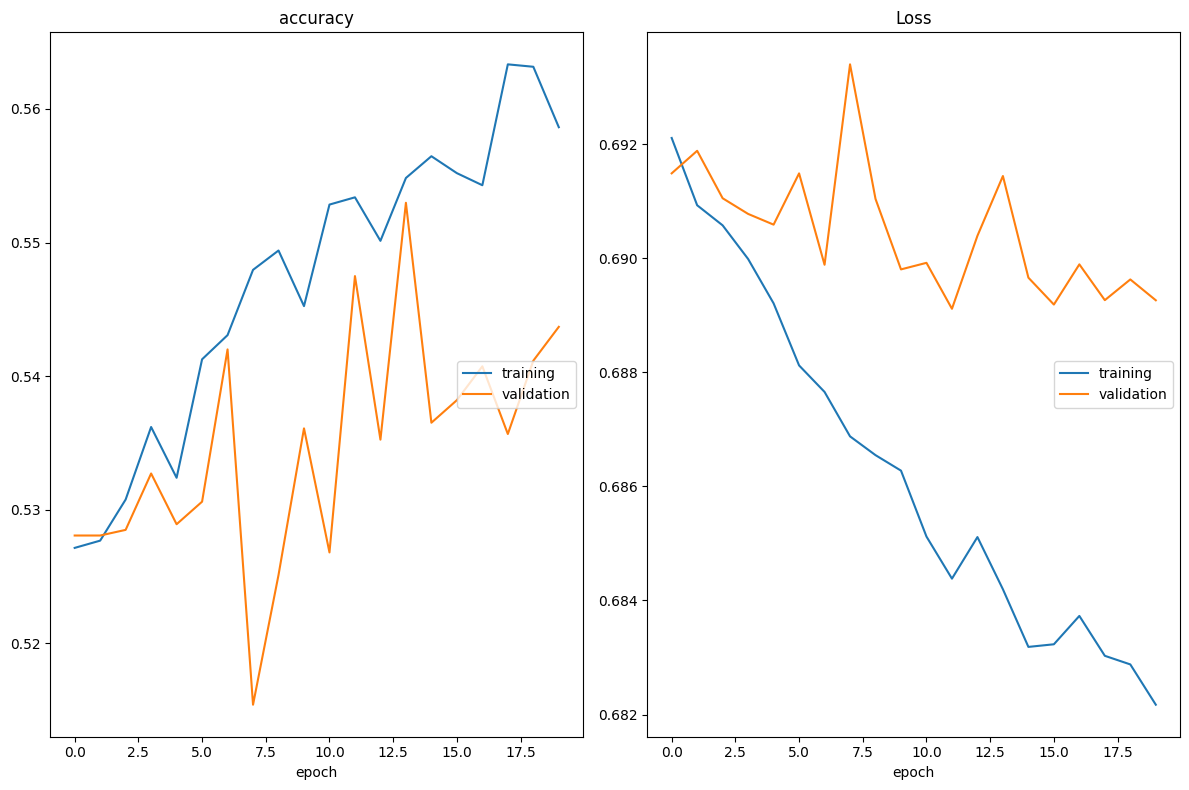

accuracy
	training         	 (min:    0.527, max:    0.563, cur:    0.559)
	validation       	 (min:    0.515, max:    0.553, cur:    0.544)
Loss
	training         	 (min:    0.682, max:    0.692, cur:    0.682)
	validation       	 (min:    0.689, max:    0.693, cur:    0.689)
44/44 [==============================] - 60s 1s/step - loss: 0.6822 - accuracy: 0.5586 - val_loss: 0.6893 - val_accuracy: 0.5437


In [23]:
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          batch_size=128, epochs=20, verbose=1,
           callbacks=[PlotLossesKeras(), early_stop]
)

In [24]:
# Evaluar el modelo en los datos de prueba
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

75/75 [==============================] - 10s 132ms/step - loss: 0.6893 - accuracy: 0.5437
Test accuracy: 0.5436893105506897


# Exercise 7.4

Create a GRU neural network to predict the rating of a movie

Calculate the testing set accuracy

In [25]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GRU, Dense

Este código crea un modelo de red neuronal con una capa GRU para clasificación binaria de texto.

In [26]:
model = Sequential()
model.add(Embedding(len(vocabulary) + 1, 128, input_length=max_len)) # Change input_length to match X_train
model.add(GRU(32))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 2000, 128)         7552      
                                                                 
 gru (GRU)                   (None, 32)                15552     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 23137 (90.38 KB)
Trainable params: 23137 (90.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Este código entrena el modelo con los datos de entrenamiento y muestra la evolución del rendimiento.

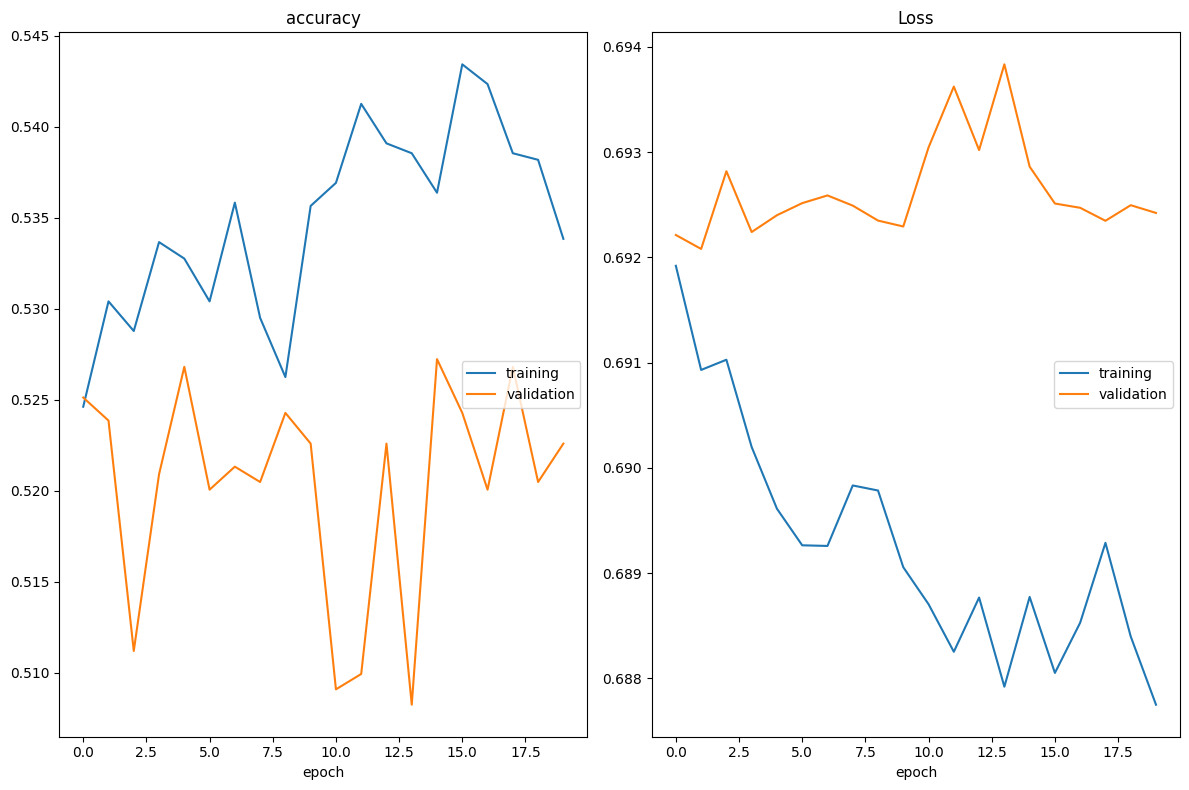

accuracy
	training         	 (min:    0.525, max:    0.543, cur:    0.534)
	validation       	 (min:    0.508, max:    0.527, cur:    0.523)
Loss
	training         	 (min:    0.688, max:    0.692, cur:    0.688)
	validation       	 (min:    0.692, max:    0.694, cur:    0.692)
44/44 [==============================] - 62s 1s/step - loss: 0.6878 - accuracy: 0.5338 - val_loss: 0.6924 - val_accuracy: 0.5226


In [27]:
model.fit(X_train, y_train, validation_data=[X_test, y_test],
          batch_size=128, epochs=20, verbose=1,
         callbacks=[PlotLossesKeras(), early_stop]
)

In [28]:
# Evaluar el modelo en los datos de prueba
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

75/75 [==============================] - 10s 138ms/step - loss: 0.6924 - accuracy: 0.5226
Test accuracy: 0.5225833654403687
